# Classification Models — Attrition Prediction

Two models,  **Logistic Regression** (interpretable baseline, genuinely
useful for an HR audience) and **LightGBM** (usually stronger on tabular data).
Whichever wins on PR-AUC gets the SHAP explanation. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    classification_report, PrecisionRecallDisplay
)
import lightgbm as lgb

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape, X_test.shape)


(1176, 62) (294, 62)


## Why PR-AUC, not accuracy

From the EDA: 84% No / 16% Yes. A model predicting "No" for everyone scores
84% accuracy while catching zero leavers — useless for retention. PR-AUC
focuses on the minority class we actually care about.


## Model 1: Logistic Regression baseline

`class_weight="balanced"` to account for the imbalance, since logistic
regression doesn't handle it natively the way boosted trees can.


In [3]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train, y_train)

logreg_probs = logreg.predict_proba(X_test)[:, 1]
logreg_ap = average_precision_score(y_test, logreg_probs)
print(f"Logistic Regression PR-AUC: {logreg_ap:.3f}")


Logistic Regression PR-AUC: 0.552


c:\Users\lenovo\Downloads\ecommerce-demand-forecasting\ecommerce-demand-forecasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
print(classification_report(y_test, (logreg_probs > 0.5).astype(int)))

              precision    recall  f1-score   support

           0       0.92      0.76      0.83       247
           1       0.33      0.64      0.44        47

    accuracy                           0.74       294
   macro avg       0.62      0.70      0.63       294
weighted avg       0.82      0.74      0.77       294



## Model 2: LightGBM

`scale_pos_weight` set from the actual train-set class ratio, not a guessed number.


In [5]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    scale_pos_weight=pos_weight,
    random_state=42,
    verbose=-1,
)
lgbm.fit(X_train, y_train)

lgbm_probs = lgbm.predict_proba(X_test)[:, 1]
lgbm_ap = average_precision_score(y_test, lgbm_probs)
print(f"LightGBM PR-AUC: {lgbm_ap:.3f}")


LightGBM PR-AUC: 0.478


In [6]:
print(classification_report(y_test, (lgbm_probs > 0.5).astype(int)))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.52      0.26      0.34        47

    accuracy                           0.84       294
   macro avg       0.70      0.61      0.63       294
weighted avg       0.82      0.84      0.82       294



## Compare the two

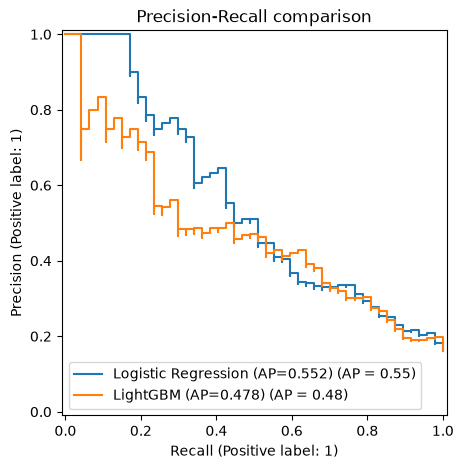

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, logreg_probs, name=f"Logistic Regression (AP={logreg_ap:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, lgbm_probs, name=f"LightGBM (AP={lgbm_ap:.3f})", ax=ax)
ax.set_title("Precision-Recall comparison")
plt.show()



## Cross-validation

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_cv = cross_val_score(logreg, X_train, y_train, cv=cv, scoring="average_precision")
lgbm_cv = cross_val_score(lgbm, X_train, y_train, cv=cv, scoring="average_precision")

print(f"Logistic Regression(5-fold CV) PR-AUC: {logreg_cv.mean():.3f} (+/- {logreg_cv.std():.3f})")
print(f"LightGBM(5-fold CV) PR-AUC: {lgbm_cv.mean():.3f} (+/- {lgbm_cv.std():.3f})")

c:\Users\lenovo\Downloads\ecommerce-demand-forecasting\ecommerce-demand-forecasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\lenovo\Downloads\ecommerce-demand-forecasting\ecommerce-demand-forecasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100

Logistic Regression(5-fold CV) PR-AUC: 0.478 (+/- 0.052)
LightGBM(5-fold CV) PR-AUC: 0.578 (+/- 0.053)


## Threshold tuning

In [12]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, logreg_probs)
target_recall = 0.80
idx = np.argmin(np.abs(recalls[:-1] - target_recall))
best_threshold = thresholds[idx]

print(f"Threshold for ~{target_recall:.0%} recall: {best_threshold:.3f}")
print(f"  -> precision at this threshold: {precisions[idx]:.3f}, recall: {recalls[idx]:.3f}")
print()
print("Classification report at this threshold:")
print(classification_report(y_test, (logreg_probs > best_threshold).astype(int)))

Threshold for ~80% recall: 0.337
  -> precision at this threshold: 0.273, recall: 0.809

Classification report at this threshold:
              precision    recall  f1-score   support

           0       0.94      0.60      0.73       247
           1       0.28      0.81      0.41        47

    accuracy                           0.63       294
   macro avg       0.61      0.70      0.57       294
weighted avg       0.84      0.63      0.68       294



## SHAP on the winner  **LightGBM**

5-fold cross-validation (cell above) is the more trustworthy comparison than
the single train/test split, since the test set only has 47 positive cases —
small enough that one split can easily favor either model by chance. On CV,
LightGBM (0.578 PR-AUC) clearly beat Logistic Regression (0.478), reversing
the single-split result. Going with LightGBM as the real winner.

Which features actually drive predicted attrition risk.

c:\Users\lenovo\Downloads\ecommerce-demand-forecasting\ecommerce-demand-forecasting\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


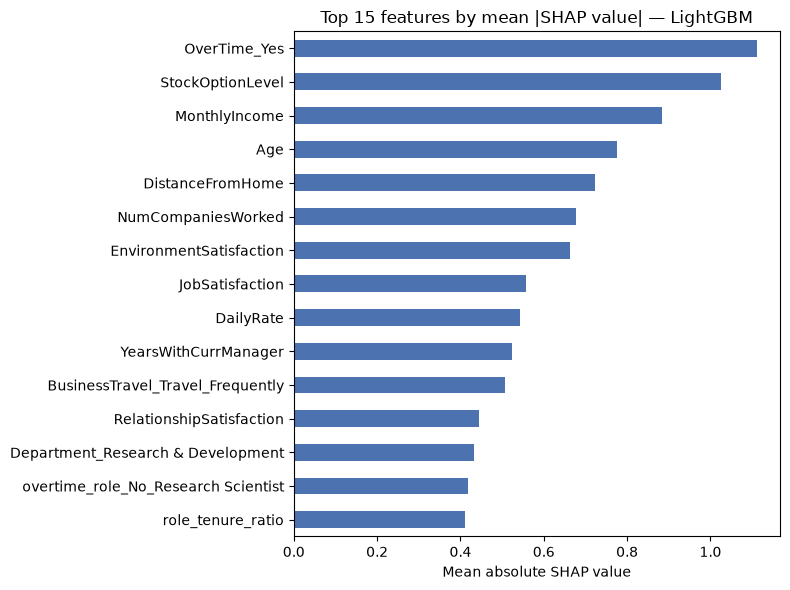

In [14]:
import shap

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(8, 6))
mean_abs_shap.head(top_n).sort_values().plot(kind="barh", color="#4C72B0")
plt.title(f"Top {top_n} features by mean |SHAP value| — LightGBM")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

## Notes

- Metric: PR-AUC (average precision), not accuracy — imbalance from the EDA makes accuracy meaningless here
- `class_weight`/`scale_pos_weight` set from the actual training data, not a default guess
- Winner picked on 5-fold CV PR-AUC, not the single train/test split — with only 47 positive cases in the test set, a single split is too noisy to trust on its own
- SHAP run only on the winner  **LightGBM**